In [ ]:
!pip install geoviews bokeh dash -q
!pip install -q panel hvplot jupyter_bokeh

import hvplot.pandas
import pandas as pd
import holoviews as hv
import panel as pn
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

pn.extension('bokeh', 'plotly', sizing_mode="stretch_width")

# ---------- LOAD & CLEAN ----------
url = "https://raw.githubusercontent.com/hganesh2024/dsci454-data/main/US_Accidents_sampled_100k.csv.gz"
df = pd.read_csv(url, compression="gzip")

df = df.dropna(subset=['Start_Lat', 'Start_Lng'])
df['City'] = df['City'].fillna('Unknown')
df['State'] = df['State'].fillna('Unknown')
df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')
df['Temperature(F)'] = df['Temperature(F)'].fillna(0)
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(0)
df['Severity'] = df['Severity'].fillna(2).astype(int)

labels = {1: '1 - Minor', 2: '2 - Moderate', 3: '3 - Serious', 4: '4 - Critical'}
df['Severity Label'] = df['Severity'].map(labels)

df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="mixed", errors="coerce")
df = df.dropna(subset=["Start_Time"])
df["Year"] = df["Start_Time"].dt.year
df["Hour"] = df["Start_Time"].dt.hour
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["Day"] = pd.Categorical(df["Start_Time"].dt.day_name(), categories=day_order, ordered=True)

HTTPError: HTTP Error 404: Not Found

In [ ]:
# ---------- GLOBAL WIDGETS (sidebar) ----------
severity_widget = pn.widgets.MultiChoice(
    name="Severity",
    value=[1, 2, 3, 4],
    options=[1, 2, 3, 4]
)

state_widget = pn.widgets.MultiChoice(
    name="State",
    value=[],  # empty = all
    options=sorted(df['State'].unique().tolist()),
    placeholder="All states"
)

year_widget = pn.widgets.IntRangeSlider(
    name="Year Range",
    start=int(df['Year'].min()),
    end=int(df['Year'].max()),
    value=(2017, 2022),
    step=1
)

# ---------- FILTERED DATA (reactive) ----------
def filter_df(severity, states, year_range):
    filtered = df[df['Severity'].isin(severity)]
    filtered = filtered[(filtered['Year'] >= year_range[0]) & (filtered['Year'] <= year_range[1])]
    if states:
        filtered = filtered[filtered['State'].isin(states)]
    return filtered

# ---------- CHARTS (all reactive to widgets) ----------
def plot_map(severity, states, year_range):
    d = filter_df(severity, states, year_range)
    if len(d) == 0:
        return pn.pane.Markdown("### No data matches filters")
    sample = d.sample(n=min(20000, len(d)), random_state=42)
    fig = px.scatter_mapbox(
        sample, lat='Start_Lat', lon='Start_Lng', color='Severity',
        color_continuous_scale=['green', 'yellow', 'orange', 'red'],
        zoom=3, height=450,
        hover_data=['City', 'State', 'Weather_Condition']
    )
    fig.update_traces(marker=dict(size=4, opacity=0.6))
    fig.update_layout(mapbox_style='carto-darkmatter', margin=dict(l=0, r=0, t=10, b=0),
                      paper_bgcolor='rgba(0,0,0,0)')
    return pn.pane.Plotly(fig, sizing_mode="stretch_width", height=450)

def plot_yearly(severity, states, year_range):
    d = filter_df(severity, states, year_range)
    yearly = d.groupby("Year").size().reset_index(name="Count")
    fig, ax = plt.subplots(figsize=(7, 3.5))
    sns.lineplot(data=yearly, x="Year", y="Count", marker="o", linewidth=2, ax=ax, color='#E74C3C')
    ax.set_title("Accidents Per Year")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.close(fig)
    return pn.pane.Matplotlib(fig, tight=True, sizing_mode="stretch_width")

def plot_kde(severity, states, year_range):
    d = filter_df(severity, states, year_range).dropna(subset=["Sunrise_Sunset"])
    fig, ax = plt.subplots(figsize=(7, 3.5))
    if len(d) > 0:
        sns.kdeplot(data=d, x="Severity", hue="Sunrise_Sunset",
                    fill=True, common_norm=False, alpha=0.5, ax=ax)
    ax.set_title("Severity: Day vs Night")
    plt.tight_layout()
    plt.close(fig)
    return pn.pane.Matplotlib(fig, tight=True, sizing_mode="stretch_width")

def plot_weather(severity, states, year_range):
    d = filter_df(severity, states, year_range)
    top = d['Weather_Condition'].value_counts().head(10)
    fig = px.bar(x=top.index, y=top.values,
                 labels={'x': 'Weather', 'y': 'Accidents'},
                 color=top.values, color_continuous_scale='Reds')
    fig.update_layout(height=400, margin=dict(l=10, r=10, t=30, b=10),
                      title="Top 10 Weather Conditions",
                      paper_bgcolor='rgba(0,0,0,0)', showlegend=False,
                      coloraxis_showscale=False)
    return pn.pane.Plotly(fig, sizing_mode="stretch_width", height=400)

def plot_heatmap(severity, states, year_range):
    d = filter_df(severity, states, year_range)
    heatmap_data = d.groupby(["Day", "Hour"], observed=True).size().reset_index(name="Count")
    return heatmap_data.hvplot.heatmap(
        x="Hour", y="Day", C="Count", cmap="Reds",
        height=400, responsive=True, title="Accidents by Day & Hour"
    )

# ---------- BIND WIDGETS TO PLOTS ----------
deps = dict(severity=severity_widget, states=state_widget, year_range=year_widget)

map_pane = pn.bind(plot_map, **deps)
yearly_pane = pn.bind(plot_yearly, **deps)
kde_pane = pn.bind(plot_kde, **deps)
weather_pane = pn.bind(plot_weather, **deps)
heatmap_pane = pn.bind(plot_heatmap, **deps)

# ---------- KPI CARDS ----------
def make_kpis(severity, states, year_range):
    d = filter_df(severity, states, year_range)
    total = pn.indicators.Number(name="Total Accidents", value=len(d),
                                  format="{value:,}", font_size="28pt", title_size="14pt")
    avg_sev = pn.indicators.Number(name="Avg Severity", value=round(d['Severity'].mean(), 2) if len(d) else 0,
                                    font_size="28pt", title_size="14pt")
    states_n = pn.indicators.Number(name="States", value=d['State'].nunique(),
                                     font_size="28pt", title_size="14pt")
    return pn.Row(total, avg_sev, states_n)

kpi_pane = pn.bind(make_kpis, **deps)

Row(sizing_mode='stretch_width')
    [0] Column(height=900, sizing_mode='fixed', styles={'background': '#2C3E50', ...}, width=280)
        [0] Markdown(str, sizing_mode='stretch_width', styles={'color': 'white'})
        [1] MultiChoice(name='Severity', options=[1, 2, 3, 4], sizing_mode='stretch_width', value=[1, 2, 3, 4])
        [2] MultiChoice(name='State', options=['AL', 'AR', 'AZ', ...], placeholder='All states', sizing_mode='stretch_width')
        [3] IntRangeSlider(end=2023, name='Year Range', sizing_mode='stretch_width', start=2016, value=(2017, 2022), value_end=2022, value_start=2017)
    [1] Column(sizing_mode='stretch_width')
        [0] Markdown(str, sizing_mode='stretch_width', styles={'background': '#2C3E50', ...})
        [1] ParamFunction(function, _pane=Row, defer_load=False, sizing_mode='stretch_width')
        [2] Card(sizing_mode='stretch_width', title='Accident Locations')
            [0] ParamFunction(function, _pane=Plotly, defer_load=False, sizing_mode='stretch_width')
        [3] Row(sizing_mode='stretch_width')
            [0] Card(sizing_mode='stretch_width', title='Yearly Trend')
                [0] ParamFunction(function, _pane=Matplotlib, defer_load=False, sizing_mode='stretch_width')
            [1] Card(sizing_mode='stretch_width', title='Day vs Night')
                [0] ParamFunction(function, _pane=Matplotlib, defer_load=False, sizing_mode='stretch_width')
        [4] Row(sizing_mode='stretch_width')
            [0] Card(sizing_mode='stretch_width', title='Weather Conditions')
                [0] ParamFunction(function, _pane=Plotly, defer_load=False, sizing_mode='stretch_width')
            [1] Card(sizing_mode='stretch_width', title='Time Heatmap')
                [0] ParamFunction(function, _pane=HoloViews, defer_load=False, sizing_mode='stretch_width')
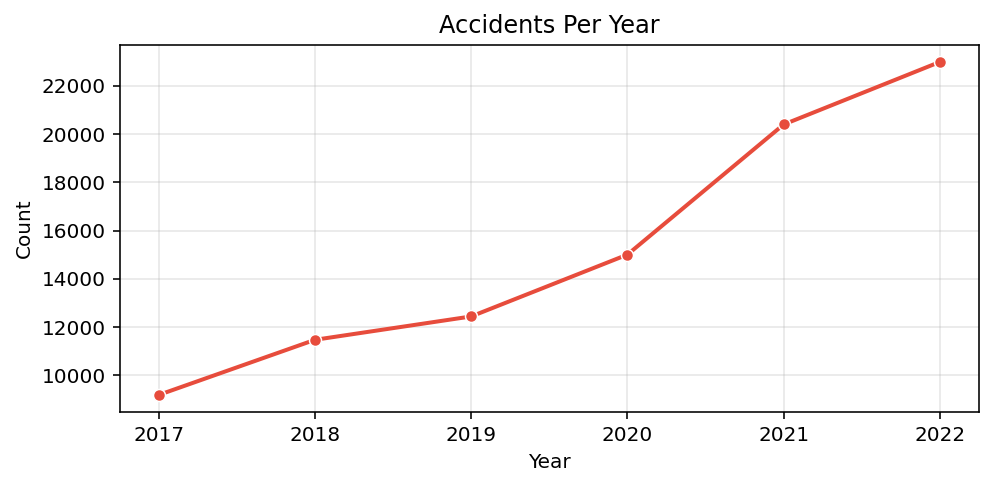
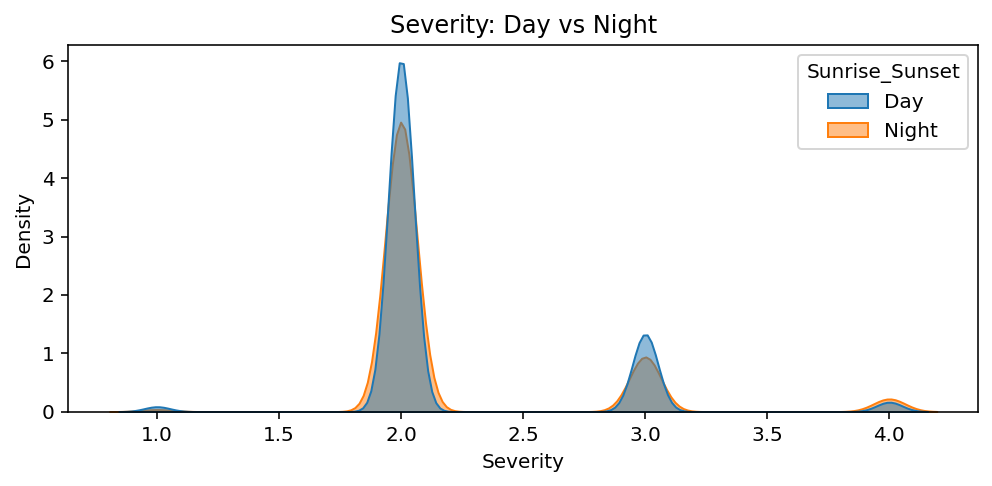

/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known 'a3e137bf-8b77-4551-8b90-533b6186a68a'

/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known '13305673-9963-456a-8323-9c1a9a053b11'

/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known '6294f9cc-fc39-4eb6-8a8e-ee1fdb1f2f7e'

/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known 'e499925e-bb6a-4d50-bdb0-42e86c762da1'

/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known '343964be-9b36-4939-9bb4-5e935d9e112f'

/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known '309e1acc-98da-4d28-9639-47ee328d65c0'



/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known 'f910f75a-6ae0-43a5-a904-0af13dbbac9e'



/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known '7ee31a7d-c1fb-451b-adba-f676987a1ff0'

/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known '1e7a6649-d49d-479a-85cf-92869b545d7f'

/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known 'a9020d65-0815-4d3d-b478-943940310af3'

/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known '677979f3-cc3b-4e53-b9e8-7cdadf7d2a34'

/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known 'c8167260-fcfe-49f1-9a68-47c537b2b8b6'

/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known 'a19e78cb-01c7-4268-8a60-7a2581579037'



In [ ]:
# sidebar styled like FastListTemplate
sidebar = pn.Column(
    pn.pane.Markdown("## 🚗 Dashboard\n### Filters", styles={'color': 'white'}),
    severity_widget,
    state_widget,
    year_widget,
    width=280,
    styles={'background': '#2C3E50', 'padding': '20px', 'color': 'white'},
    height=900
)

# main content area
main = pn.Column(
    pn.pane.Markdown("# US Traffic Accidents Dashboard",
                     styles={'background': '#2C3E50', 'color': 'white', 'padding': '15px'}),
    kpi_pane,
    pn.Card(map_pane, title="Accident Locations"),
    pn.Row(
        pn.Card(yearly_pane, title="Yearly Trend"),
        pn.Card(kde_pane, title="Day vs Night"),
    ),
    pn.Row(
        pn.Card(weather_pane, title="Weather Conditions"),
        pn.Card(heatmap_pane, title="Time Heatmap"),
    ),
    sizing_mode="stretch_width"
)

dashboard = pn.Row(sidebar, main)
dashboard